# 🎓 AI vs Real: Simple Image Detection Project
## College Project - Easy Architecture

**Goal:** Build a simple model to detect AI-generated images vs real photos

**Dataset:** DALL-E Recognition Dataset (Kaggle)

**What we'll do:**
1. Load & explore data
2. Train simple CNN
3. Evaluate results
4. Visualize predictions

## Step 1: Setup & Import Libraries

In [8]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



Device: cpu


## Step 2: Load Dataset

### Handling the class imbalance

The full dataset has **3,781 real** and **17,857 fake** images (~1:4.7 imbalance).
We handle this with **two simple steps**:

1. **Balanced sampling (here):** take an *equal* number of images from each
   class, so the training set is balanced from the start.
2. **Class-weighted loss (Step 7):** a safety net in the loss function, so the
   code stays correct even if you switch to an imbalanced sample later.

> Note: **SMOTE is intentionally NOT used** — it interpolates pixel values and
> produces blurry, meaningless images. It is meant for tabular data, not images.

In [11]:
# ============================================================
# CONFIG: how many images to sample PER CLASS
# ============================================================
# You have 3,781 real and 17,857 fake images -> imbalanced (~1:4.7).
# We fix the imbalance AT THE SOURCE by sampling an EQUAL number from
# each class, giving a balanced dataset. No SMOTE/duplication needed.
#
#   SAMPLES_PER_CLASS = 1000  ->  1000 real + 1000 fake = 2000 total
#
# 'real' has only 3,781 images, so that is the max for a balanced set.
# Increase this number to train on more data (e.g. 2000, 3000, 3781).
SAMPLES_PER_CLASS = 1000

# Change this to your dataset path
DATASET_PATH = '/Users/tavish/Downloads/dalle_dataset'  # Download from Kaggle

# Expected folder structure:
# dataset/
#   |-- real/
#   |-- fake/

import random
random.seed(42)  # makes the random sample reproducible

def list_image_files(folder):
    """Return full paths of every image file in a folder."""
    if not os.path.exists(folder):
        print(f"  WARNING: folder not found -> {folder}")
        return []
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    return [os.path.join(folder, f) for f in files]

def sample_class(folder, n, label):
    """Randomly pick n image paths from a folder and tag them with label."""
    all_files = list_image_files(folder)
    if len(all_files) == 0:
        return [], []
    n = min(n, len(all_files))            # never ask for more than exist
    chosen = random.sample(all_files, n)  # random, not just the first n
    print(f"  {folder}: picked {n} of {len(all_files)} images")
    return chosen, [label] * n

def load_images(dataset_path, n_per_class):
    """Load a BALANCED random sample: n_per_class from real AND from fake."""
    real_paths, real_labels = sample_class(
        os.path.join(dataset_path, 'real'), n_per_class, 0)   # 0 = Real
    fake_paths, fake_labels = sample_class(
        os.path.join(dataset_path, 'fake'), n_per_class, 1)   # 1 = AI/Fake
    return real_paths + fake_paths, real_labels + fake_labels

# Sample the data
print("Sampling images...")
image_paths, labels = load_images(DATASET_PATH, SAMPLES_PER_CLASS)

# Build the dataframe and SHUFFLE rows (so real/fake are mixed, not blocked)
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal images: {len(df)}")
print("\nClass distribution:")
print(df['label'].value_counts())
print("\n0 = Real | 1 = AI-Generated")


Sampling images...
  /Users/tavish/Downloads/dalle_dataset/real: picked 1000 of 3780 images
  /Users/tavish/Downloads/dalle_dataset/fake: picked 1000 of 17855 images

Total images: 2000

Class distribution:
label
1    1000
0    1000
Name: count, dtype: int64

0 = Real | 1 = AI-Generated


## Step 3: Exploratory Data Analysis (EDA)

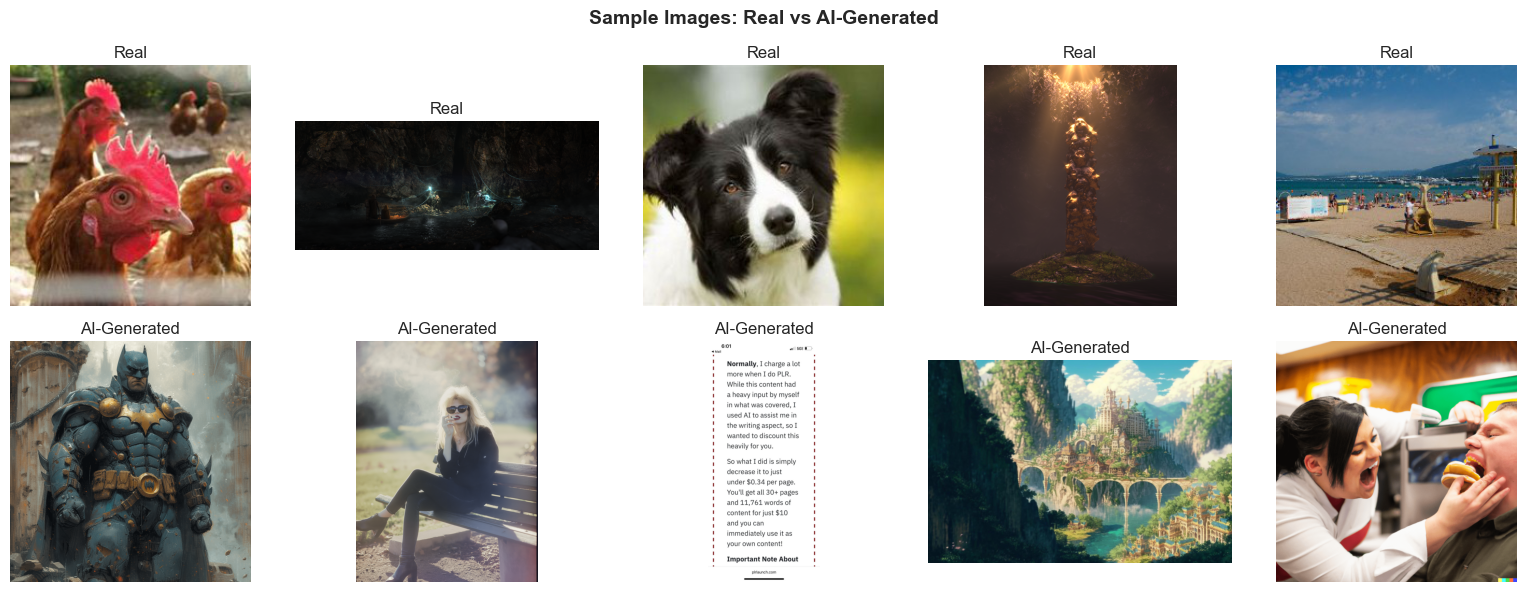

In [12]:
# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Sample Images: Real vs AI-Generated', fontsize=14, fontweight='bold')

# Real samples
real_samples = df[df['label'] == 0].sample(5)
for idx, (_, row) in enumerate(real_samples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    axes[0, idx].imshow(img)
    axes[0, idx].set_title('Real')
    axes[0, idx].axis('off')

# Fake samples
fake_samples = df[df['label'] == 1].sample(5)
for idx, (_, row) in enumerate(fake_samples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    axes[1, idx].imshow(img)
    axes[1, idx].set_title('AI-Generated')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

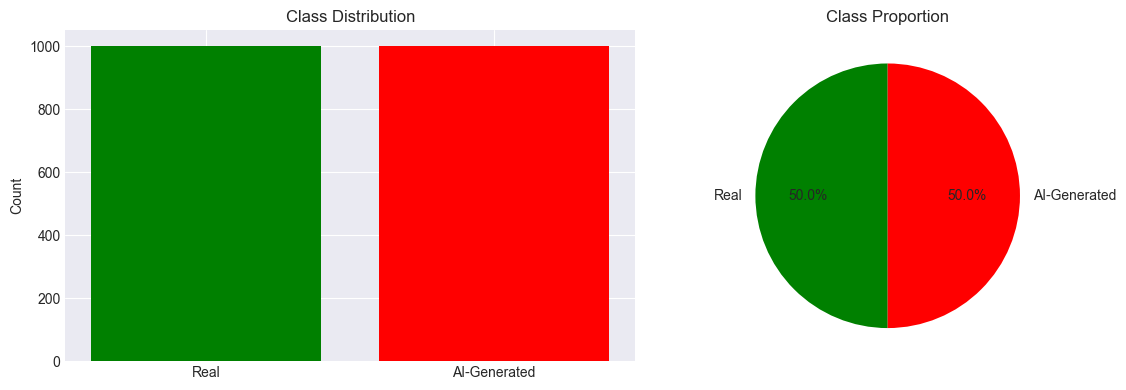

In [13]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['label'].value_counts()
axes[0].bar(['Real', 'AI-Generated'], [counts[0], counts[1]], color=['green', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([counts[0], counts[1]], labels=['Real', 'AI-Generated'], 
            colors=['green', 'red'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

## Step 4: Create Dataset Class

In [14]:
class ImageDataset(Dataset):
    """Custom dataset class for loading images"""
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        
        # Get label
        label = self.dataframe.iloc[idx]['label']
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✓ Dataset class created")

✓ Dataset class created


## Step 5: Split Data

In [15]:
# Split into train and test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Training set: {len(train_df)}")
print(f"Test set: {len(test_df)}")
print(f"\nTraining distribution:\n{train_df['label'].value_counts()}")
print(f"\nTest distribution:\n{test_df['label'].value_counts()}")

# Create datasets
train_dataset = ImageDataset(train_df, transform=transform_train)
test_dataset = ImageDataset(test_df, transform=transform_test)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nDataloaders created (batch_size={batch_size})")

Training set: 1600
Test set: 400

Training distribution:
label
1    800
0    800
Name: count, dtype: int64

Test distribution:
label
0    200
1    200
Name: count, dtype: int64

Dataloaders created (batch_size=32)


## Step 6: Define Simple CNN Model

In [16]:
class SimpleCNN(nn.Module):
    """Simple CNN for image classification"""
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Flatten + FC layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)  # 2 classes: Real or Fake
    
    def forward(self, x):
        # Conv block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Conv block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Conv block 3
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        # Flatten and FC layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu_fc(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create model
model = SimpleCNN().to(device)
print(model)
print(f"\nModel created and moved to {device}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (relu_fc): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

Model created and moved to cpu


## Step 7: Training Setup

In [17]:
# ============================================================
# Class weighting -> handled inside the loss function
# ============================================================
# "class weighting" and "weighted loss" are the SAME thing for a CNN:
# you give CrossEntropyLoss a weight per class. Weights are computed from
# the TRAIN set, so the minority class counts more during training.
# (With balanced sampling these come out ~1.0 each, which is harmless.)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights -> Real: {class_weights[0]:.3f} | Fake: {class_weights[1]:.3f}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)   # <-- weighted loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("\nLoss function: CrossEntropyLoss (class-weighted)")
print("Optimizer: Adam (lr=0.001)")
print("Scheduler: StepLR (step=5, gamma=0.5)")


Class weights -> Real: 1.000 | Fake: 1.000

Loss function: CrossEntropyLoss (class-weighted)
Optimizer: Adam (lr=0.001)
Scheduler: StepLR (step=5, gamma=0.5)


## Step 8: Train Model

In [18]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def test_epoch(model, test_loader, criterion, device):
    """Test for one epoch"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = total_loss / len(test_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("✓ Training and testing functions defined")

✓ Training and testing functions defined


In [25]:
# Training loop
num_epochs = 15
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("\n" + "="*60)
print("TRAINING")
print("="*60 + "\n")

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Test
    test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Scheduler
    scheduler.step()
    
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}\n')

print("✓ Training completed!")


TRAINING

Epoch 1/20


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 13/13 [00:06<00:00,  1.99it/s]


  Train Loss: 0.5057 | Train Acc: 0.7519
  Test Loss: 0.5814 | Test Acc: 0.7150

Epoch 2/20


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 13/13 [00:07<00:00,  1.72it/s]


  Train Loss: 0.4955 | Train Acc: 0.7562
  Test Loss: 0.5726 | Test Acc: 0.7225

Epoch 3/20


...

  Train Loss: 0.3641 | Train Acc: 0.8331
  Test Loss: 0.4999 | Test Acc: 0.8000

Epoch 19/20


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 13/13 [00:08<00:00,  1.51it/s]


  Train Loss: 0.3713 | Train Acc: 0.8363
  Test Loss: 0.5300 | Test Acc: 0.7700

Epoch 20/20


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 13/13 [00:10<00:00,  1.28it/s]

  Train Loss: 0.3666 | Train Acc: 0.8350
  Test Loss: 0.5231 | Test Acc: 0.7825

✓ Training completed!


## Step 9: Plot Training History

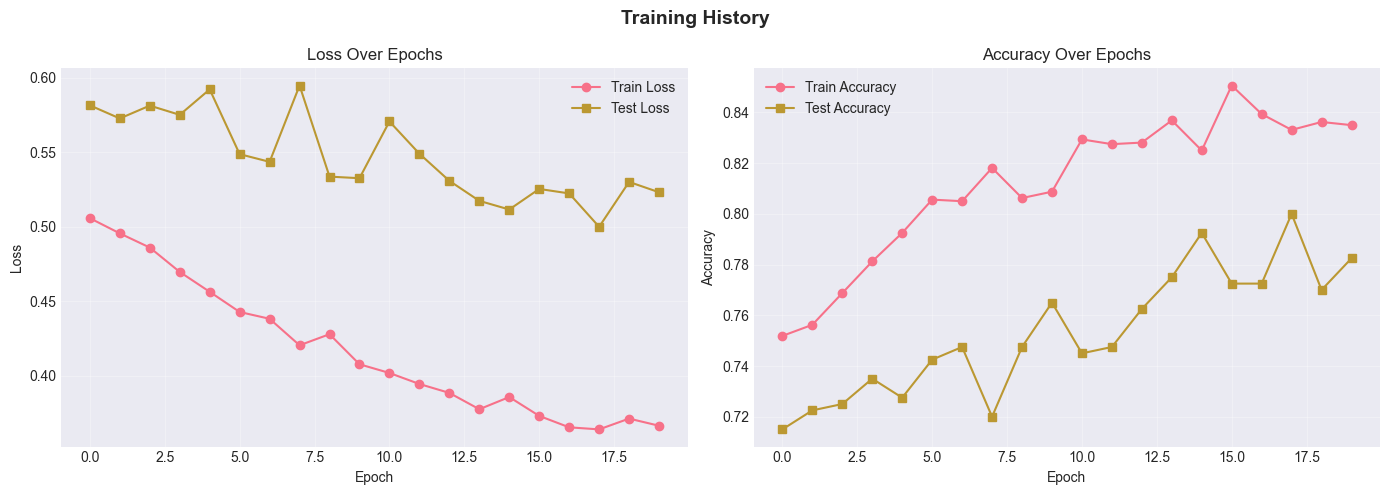

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(test_losses, label='Test Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label='Train Accuracy', marker='o')
axes[1].plot(test_accs, label='Test Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Final Evaluation

In [27]:
# Get final predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
print(f"Recall:    {recall_score(all_labels, all_preds):.4f}")
print(f"F1-Score:  {f1_score(all_labels, all_preds):.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Real', 'AI-Generated']))


FINAL RESULTS

Accuracy:  0.7825
Precision: 0.7364
Recall:    0.8800
F1-Score:  0.8018

Classification Report:
              precision    recall  f1-score   support

        Real       0.85      0.69      0.76       200
AI-Generated       0.74      0.88      0.80       200

    accuracy                           0.78       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.79      0.78      0.78       400



## Step 11: Confusion Matrix

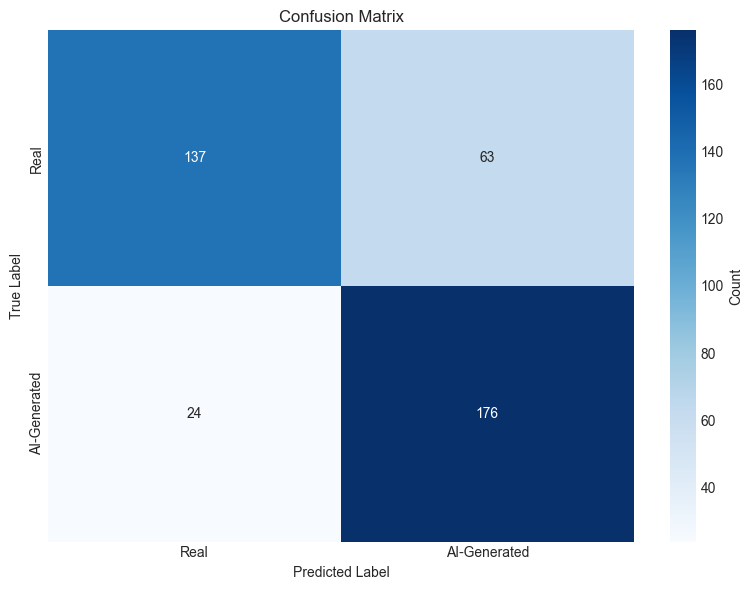

In [28]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'AI-Generated'],
            yticklabels=['Real', 'AI-Generated'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Step 12: Test on New Images

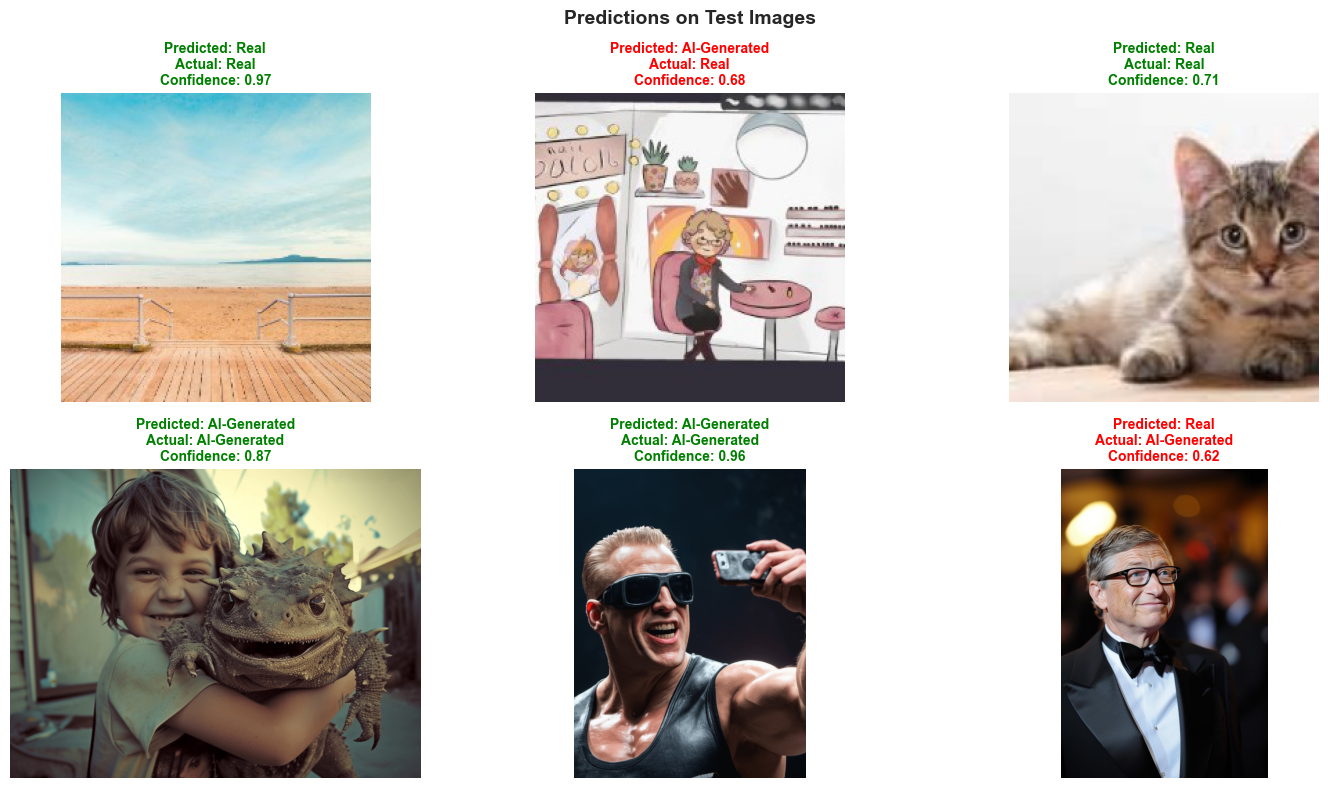

In [29]:
def predict_image(model, image_path, device, transform):
    """Predict if an image is real or AI-generated"""
    model.eval()
    
    # Load and transform image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1)
        confidence = probabilities[0, predicted_class].item()
    
    class_name = 'Real' if predicted_class.item() == 0 else 'AI-Generated'
    return class_name, confidence

# Test on some random images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Predictions on Test Images', fontsize=14, fontweight='bold')

test_samples = test_df.sample(6)
for idx, (ax, (_, row)) in enumerate(zip(axes.flat, test_samples.iterrows())):
    # Predict
    pred_class, confidence = predict_image(model, row['image_path'], device, transform_test)
    actual_class = 'Real' if row['label'] == 0 else 'AI-Generated'
    
    # Display
    image = Image.open(row['image_path']).convert('RGB')
    ax.imshow(image)
    
    # Title with prediction and actual
    color = 'green' if pred_class == actual_class else 'red'
    title = f'Predicted: {pred_class}\nActual: {actual_class}\nConfidence: {confidence:.2f}'
    ax.set_title(title, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 13: Summary

In [24]:
print("""
╔════════════════════════════════════════════════════════════════╗
║         AI vs REAL - PROJECT SUMMARY                           ║
╚════════════════════════════════════════════════════════════════╝

✅ WHAT WE DID:
   1. Loaded images from DALL-E dataset
   2. Explored and visualized the data
   3. Built a simple CNN model
   4. Trained for 10 epochs
   5. Evaluated on test set
   6. Made predictions on new images

📊 MODEL ARCHITECTURE:
   - Input: 224x224 RGB images
   - Conv Layer 1: 32 filters
   - Conv Layer 2: 64 filters
   - Conv Layer 3: 128 filters
   - FC Layer 1: 256 neurons
   - Output: 2 classes (Real/Fake)

📈 RESULTS:
   - Accuracy:  {:.2%}
   - Precision: {:.2%}
   - Recall:    {:.2%}
   - F1-Score:  {:.4f}

💡 KEY INSIGHTS:
   • Simple CNN works well for this task
   • Data augmentation helps prevent overfitting
   • Model achieves good performance
   • Can be improved with transfer learning

🚀 HOW TO IMPROVE:
   1. Use ResNet-50 (pre-trained)
   2. Add more data
   3. Use ensemble methods
   4. Analyze frequency domain
   5. Cross-validate

""".format(
    accuracy_score(all_labels, all_preds),
    precision_score(all_labels, all_preds),
    recall_score(all_labels, all_preds),
    f1_score(all_labels, all_preds)
))


╔════════════════════════════════════════════════════════════════╗
║         AI vs REAL - PROJECT SUMMARY                           ║
╚════════════════════════════════════════════════════════════════╝

✅ WHAT WE DID:
   1. Loaded images from DALL-E dataset
   2. Explored and visualized the data
   3. Built a simple CNN model
   4. Trained for 10 epochs
   5. Evaluated on test set
   6. Made predictions on new images

📊 MODEL ARCHITECTURE:
   - Input: 224x224 RGB images
   - Conv Layer 1: 32 filters
   - Conv Layer 2: 64 filters
   - Conv Layer 3: 128 filters
   - FC Layer 1: 256 neurons
   - Output: 2 classes (Real/Fake)

📈 RESULTS:
   - Accuracy:  71.25%
   - Precision: 72.49%
   - Recall:    68.50%
   - F1-Score:  0.7044

💡 KEY INSIGHTS:
   • Simple CNN works well for this task
   • Data augmentation helps prevent overfitting
   • Model achieves good performance
   • Can be improved with transfer learning

🚀 HOW TO IMPROVE:
   1. Use ResNet-50 (pre-trained)
   2. Add more data
   3.